# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository. The first three columns denote different parameters obtained from the photographs of the banknotes and last colum provides the label. Frankly as the dataset does not have any description I don't know  which labels corresponds to real and which to counterfeited banknotes. let's assume that label one (positive) denotes the clounterfeits. The set  [banknote_authentication.csv](./data/banknote_authentication.csv) can be found in the `data`  directory.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [8]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [9]:
import  matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(8,8)

Please insert you  firstname  and name below
Viktoriia Iashchuk

In [30]:
from  sklearn.model_selection import train_test_split

my_name = 'Viktoriia Iashchuk'
seed = sum(ord(c) for c in my_name)

print(seed)
# seed = 31287

1794


In [31]:
data = pd.read_csv('data/banknotes_data.csv')

In [32]:
data.head()

,a0,a1,a2,a3,counterfeit
0,-1.1306,1.8458,-1.35750,-1.38060,1
1,-1.1188,3.3357,-1.34550,-1.95730,1
2,2.6719,3.0646,0.37158,0.58619,0
3,-4.1409,3.4619,-0.47841,-3.88790,1
4,1.4507,8.7903,-2.23240,-0.65259,0


In [33]:
data.describe()

,a0,a1,a2,a3,counterfeit
count,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000
mean,0.431116,1.902054,1.426607,-1.220393,0.444254
std,2.845672,5.942260,4.397341,2.101777,0.497096
min,-7.042100,-13.773100,-5.286100,-7.871900,0.000000
25%,-1.770900,-1.916200,-1.664300,-2.466150,0.000000
50%,0.471345,2.408650,0.567365,-0.614450,0.000000
75%,2.816925,6.800675,3.338825,0.394810,1.000000
max,6.824800,12.730200,17.927400,2.449500,1.000000


In [34]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a0           1166 non-null   float64
 1   a1           1166 non-null   float64
 2   a2           1166 non-null   float64
 3   a3           1166 non-null   float64
 4   counterfeit  1166 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 45.7 KB


In [35]:
data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, stratify=data.loc[:,'counterfeit'], random_state=seed)

In [36]:
data_train

,a0,a1,a2,a3,counterfeit
723,-2.534600,-0.77392,3.36020,0.00171,1
307,3.435900,0.66216,2.10410,1.89220,0
983,4.213400,-2.80600,2.01160,0.67412,0
111,-4.676500,-5.66360,10.96900,-0.33449,1
42,3.779100,2.57620,1.30980,0.56550,0
...,...,...,...,...,...
991,2.212300,-5.83950,7.76870,-0.85302,0
387,-0.960700,2.69630,-3.12260,-1.31210,1
1086,2.969500,5.62220,0.27561,-1.15560,0
943,2.555900,3.36050,2.03210,0.26809,0


In [37]:
lbls_train = data_train['counterfeit']
lbls_test = data_test['counterfeit']

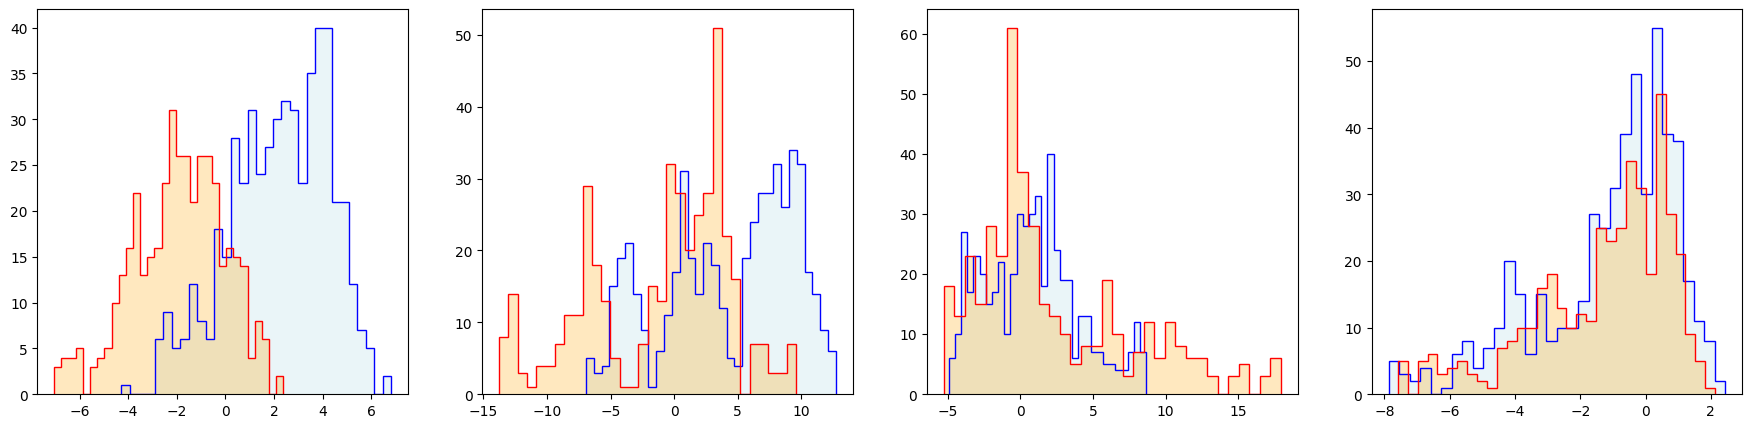

In [38]:
fig, ax = plt.subplots(1,4, figsize=(22,5))
for i in range(4):
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='step', color='blue')
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='step', color='red')
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='bar', color='lightblue', alpha=0.25)
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='bar', color='orange', alpha =0.25)

## Problem 1

Using  the [GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html) function construct the  Gaussian  Bayes classifier using only one feature. Which feature will you choose? Calculate the confusion matrix (normalized as to show rates), ROC AUC score and plot ROC curve. Do this both for training and validation set. Plot both curves on the same plot.  

In [39]:
from sklearn.naive_bayes import GaussianNB

__Hint__ For calculating metrics and plotting ROC curves you may use functions from scikit-learn: `roc_curve`, `roc_auc_score` and `confusion matrix`. For estimating normal distribution parameters  use `norm.fit` `from scipy.stats`. Use `norm.pdf` for normal probability density function.

In [40]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

Which feature did you choose?

a0. Histograms showed that a0 separates better than any other feature and I checked it by testing all features one by one.

In [41]:
features = ['a0', 'a1', 'a2', 'a3']

best_feature = None
best_auc = -1

for feature in features:
    model = GaussianNB()
    model.fit(data_train[[feature]], lbls_train)
    
    proba_train = model.predict_proba(data_train[[feature]])[:, 1]
    proba_test  = model.predict_proba(data_test[[feature]])[:, 1]
    
    auc_train = roc_auc_score(lbls_train, proba_train)
    auc_test  = roc_auc_score(lbls_test,  proba_test)

    
    print(f'Feature: {feature}, AUC train: {auc_train:.4f}, AUC validation: {auc_test:.4f}')
    
    if auc_test > best_auc:
        best_auc = auc_test
        best_feature = feature


print(f'Best Feature: {best_feature}, AUC validation: {best_auc:.4f}')

Feature: a0, AUC train: 0.9264, AUC validation: 0.9280
Feature: a1, AUC train: 0.7469, AUC validation: 0.7836
Feature: a2, AUC train: 0.5600, AUC validation: 0.6118
Feature: a3, AUC train: 0.5323, AUC validation: 0.4853
Best Feature: a0, AUC validation: 0.9280


In [42]:
clf = GaussianNB()
clf.fit(data_train[[best_feature]], lbls_train)

pred_train = clf.predict(data_train[[best_feature]])
pred_test  = clf.predict(data_test[[best_feature]])

proba_train = clf.predict_proba(data_train[[best_feature]])[:, 1]
proba_test  = clf.predict_proba(data_test[[best_feature]])[:, 1]

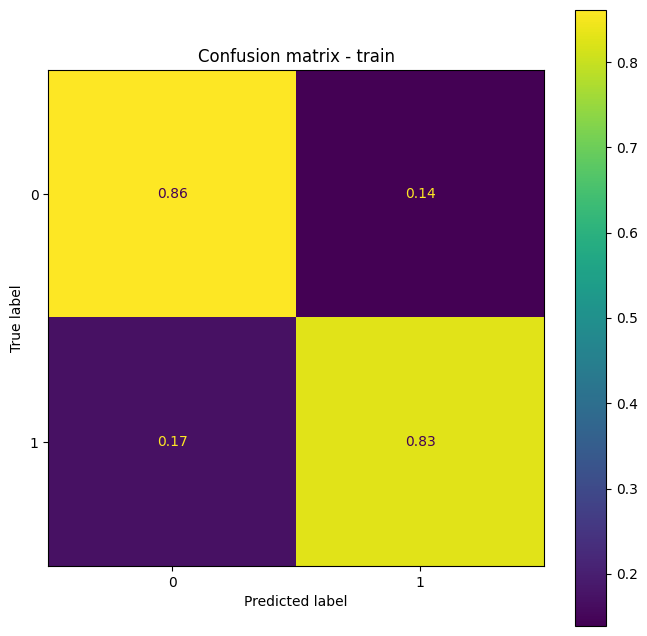

In [43]:
cm_train = confusion_matrix(lbls_train, pred_train, normalize='true')
ConfusionMatrixDisplay(cm_train).plot()
plt.title('Confusion matrix - train')
plt.show()

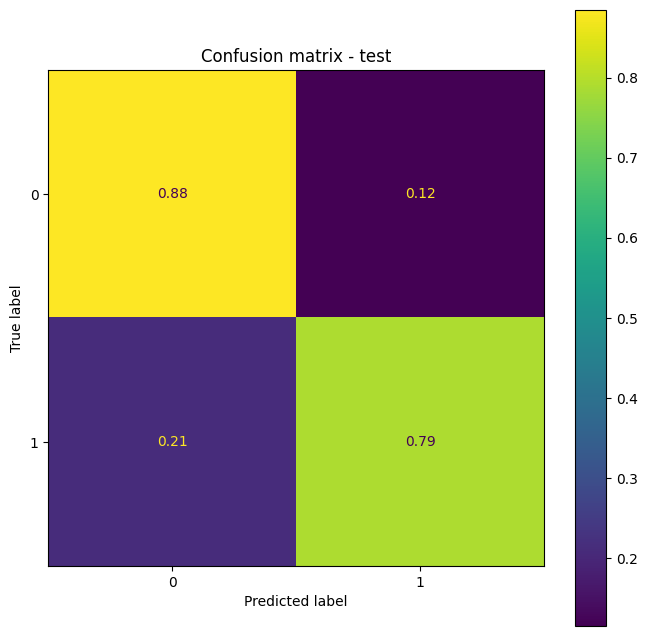

In [44]:
cm_test = confusion_matrix(lbls_test, pred_test, normalize='true')
ConfusionMatrixDisplay(cm_test).plot()
plt.title('Confusion matrix - test')
plt.show()

In [45]:
auc_train = roc_auc_score(lbls_train, proba_train)
auc_test  = roc_auc_score(lbls_test,  proba_test)

print(f'ROC AUC (train) = {auc_train:.4f}')
print(f'ROC AUC (test)  = {auc_test:.4f}')

ROC AUC (train) = 0.9264
ROC AUC (test)  = 0.9280


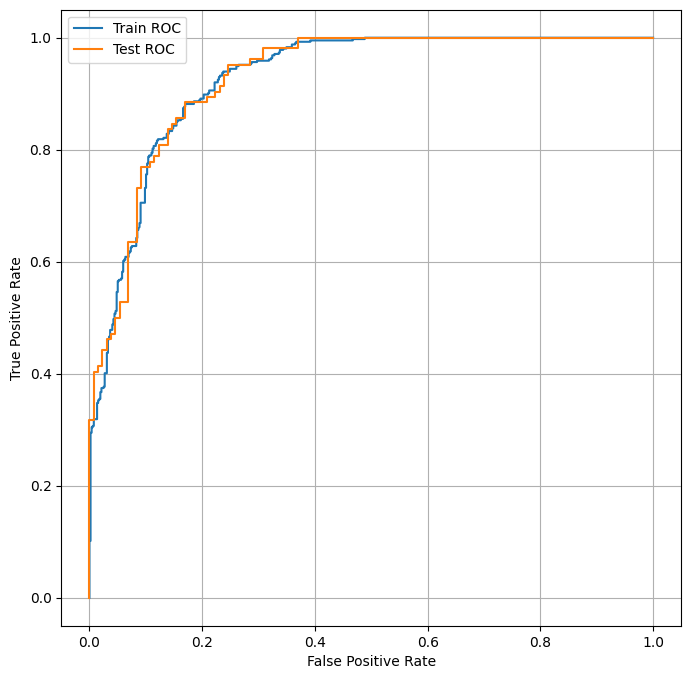

In [46]:
fpr_train, tpr_train, _ = roc_curve(lbls_train, proba_train)
fpr_test,  tpr_test,  _ = roc_curve(lbls_test,  proba_test)

plt.figure(figsize=(8, 8))
plt.plot(fpr_train, tpr_train, label=f'Train ROC')
plt.plot(fpr_test,  tpr_test,  label=f'Test ROC')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
data_train

,a0,a1,a2,a3,counterfeit
723,-2.534600,-0.77392,3.36020,0.00171,1
307,3.435900,0.66216,2.10410,1.89220,0
983,4.213400,-2.80600,2.01160,0.67412,0
111,-4.676500,-5.66360,10.96900,-0.33449,1
42,3.779100,2.57620,1.30980,0.56550,0
...,...,...,...,...,...
991,2.212300,-5.83950,7.76870,-0.85302,0
387,-0.960700,2.69630,-3.12260,-1.31210,1
1086,2.969500,5.62220,0.27561,-1.15560,0
943,2.555900,3.36050,2.03210,0.26809,0
